<a href="https://colab.research.google.com/github/SeratAftab131/Fake-Job-Detection/blob/main/Fake_Job_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("fake_job_postings.csv")
df.head()

Saving fake_job_postings.csv to fake_job_postings.csv


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
df.shape

(17880, 18)

In [ ]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [ ]:
text_cols = ["description", "requirements", "company_profile", "benefits"]

for col in text_cols:
    df[col] = df[col].fillna("")

In [ ]:
df[text_cols].isnull().sum()

,0
description,0
requirements,0
company_profile,0
benefits,0


In [ ]:
df["text"] = df["description"] + " " + df["requirements"] + " " + df["company_profile"] + " " + df["benefits"]

In [ ]:
df["text"].head()

,text
0,"Food52, a fast-growing, James Beard Award-winn..."
1,Organised - Focused - Vibrant - Awesome!Do you...
2,"Our client, located in Houston, is actively se..."
3,THE COMPANY: ESRI – Environmental Systems Rese...
4,JOB TITLE: Itemization Review ManagerLOCATION:...


In [ ]:
df["missing_salary"] = df["salary_range"].isnull().astype(int)
df["no_profile"] = (df["company_profile"] == "").astype(int)
df["no_benefits"] = (df["benefits"] == "").astype(int)
df["no_logo"] = (df["has_company_logo"] == 0).astype(int)
df["no_questions"] = (df["has_questions"] == 0).astype(int)

In [ ]:
keywords = ["urgent", "immediately", "quick", "earn money", "work from home"]

for word in keywords:
    df[word] = df["text"].str.lower().str.contains(word).astype(int)

In [ ]:
df["fraudulent"].value_counts()

,count
fraudulent,
0,17014
1,866


In [ ]:
df["fraudulent"].value_counts(normalize=True) * 100

,proportion
fraudulent,
0,95.1566
1,4.8434


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["fraudulent"],
    random_state=42
)

In [ ]:
train_df["fraudulent"].value_counts()

,count
fraudulent,
0,13611
1,693


In [ ]:
test_df["fraudulent"].value_counts()

,count
fraudulent,
0,3403
1,173


In [ ]:
len(train_df)

14304

In [ ]:
len(test_df)

3576

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_text = tfidf.fit_transform(train_df["text"])

In [ ]:
feature_cols = [
    "missing_salary",
    "no_profile",
    "no_benefits",
    "no_logo",
    "no_questions"
] + [col for col in train_df.columns if col not in df.columns]

In [ ]:
X_struct = train_df[feature_cols].values

In [ ]:
from scipy.sparse import hstack

X_train = hstack([X_text, X_struct])
y_train = train_df["fraudulent"]

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

LinearSVC()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
X_test_text = tfidf.transform(test_df["text"])

In [ ]:
X_test_struct = test_df[feature_cols].values

In [ ]:
from scipy.sparse import hstack

X_test = hstack([X_test_text, X_test_struct])

In [ ]:
y_test = test_df["fraudulent"]

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("SVM")
print(classification_report(y_test, y_pred_svm))

print("KNN")
print(classification_report(y_test, y_pred_knn))

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.43      0.60       173

    accuracy                           0.97      3576
   macro avg       0.99      0.71      0.79      3576
weighted avg       0.97      0.97      0.97      3576

Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.97      0.59      0.73       173

    accuracy                           0.98      3576
   macro avg       0.98      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576

SVM
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.94      0.72      0.82       173

    accuracy                           0.98      3576
   macro avg       0.96      0.86      0.90      3576
weighted avg       0.98      0.98   

In [ ]:
from sklearn.metrics import accuracy_score

print("LR:", accuracy_score(y_test, y_pred_lr))
print("RF:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("KNN:", accuracy_score(y_test, y_pred_knn))

LR: 0.9723154362416108
RF: 0.9793064876957495
SVM: 0.9843400447427293
KNN: 0.9756711409395973


In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
model = rf

In [ ]:
explainer = shap.TreeExplainer(model)

In [ ]:
X_test = X_test.tocsr()

In [ ]:
X_sample = X_test[:100].toarray()

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

In [ ]:
print(X_sample.shape)
print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 5005)
(5005, 2)
(5005, 2)


In [ ]:
print(X_train.shape)

(14304, 5005)


In [ ]:
X_train = X_train.tocsr()

In [ ]:
X_sample = X_train[:100].toarray()

In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

In [ ]:
print(X_sample.shape)
print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 5005)
(5005, 2)
(5005, 2)


In [ ]:
print(X_sample.shape)
print(shap_values[1].shape)

(100, 5005)
(5005, 2)


In [ ]:
print(X_sample.shape)
print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 5005)
(5005, 2)
(5005, 2)


/tmp/ipykernel_13038/2165316078.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,1], X_sample)


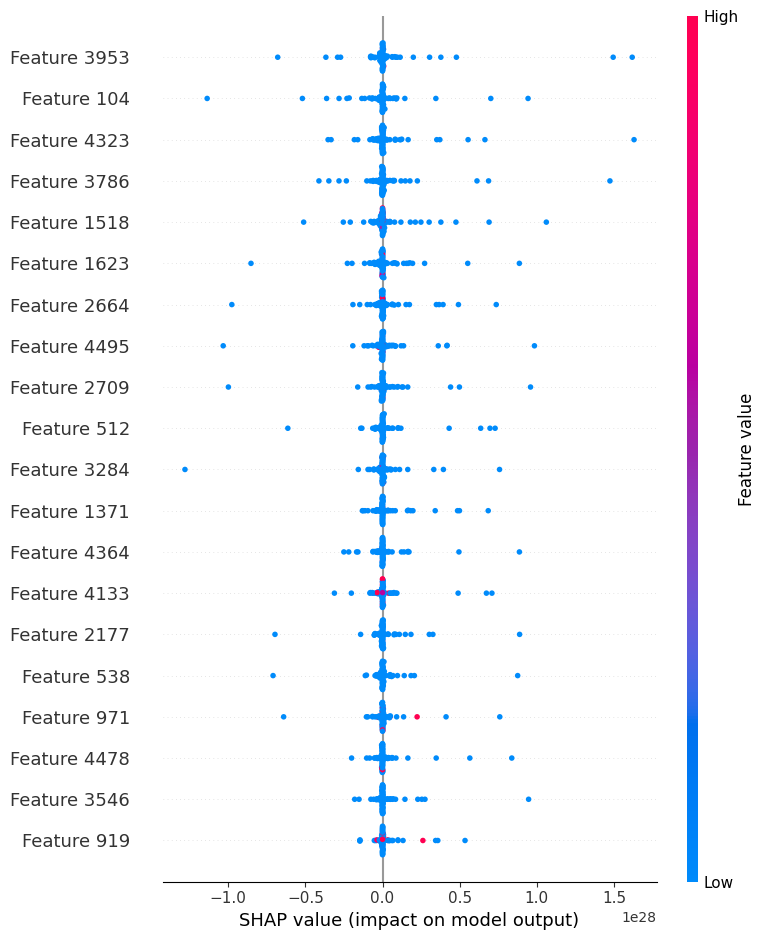

In [ ]:
shap.summary_plot(shap_values[:,:,1], X_sample)

In [ ]:
print(X_sample.shape)
print(len(shap_values))
print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 5005)
100
(5005, 2)
(5005, 2)


In [ ]:
import shap

explainer = shap.Explainer(rf, X_sample)
shap_values = explainer(X_sample)

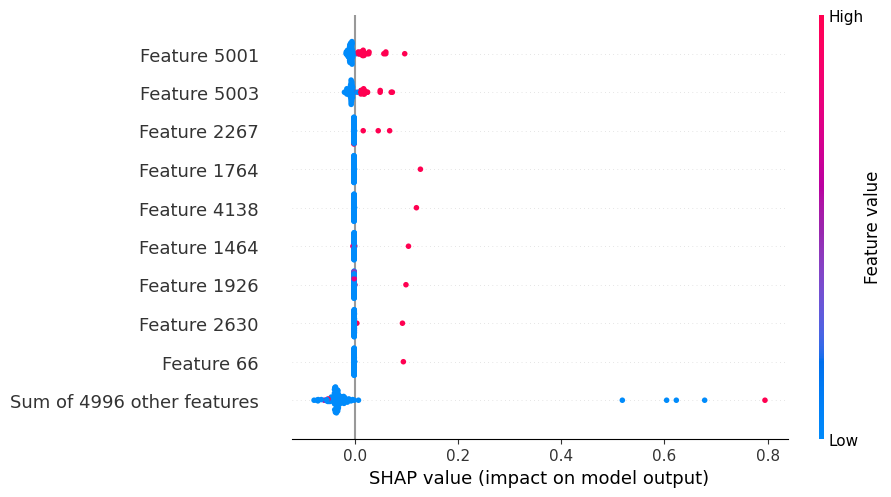

In [ ]:
shap.plots.beeswarm(shap_values[:,:, 1])

In [ ]:
feature_names = list(tfidf.get_feature_names_out()) + feature_cols
X_sample.shape[1] == len(feature_names)

True

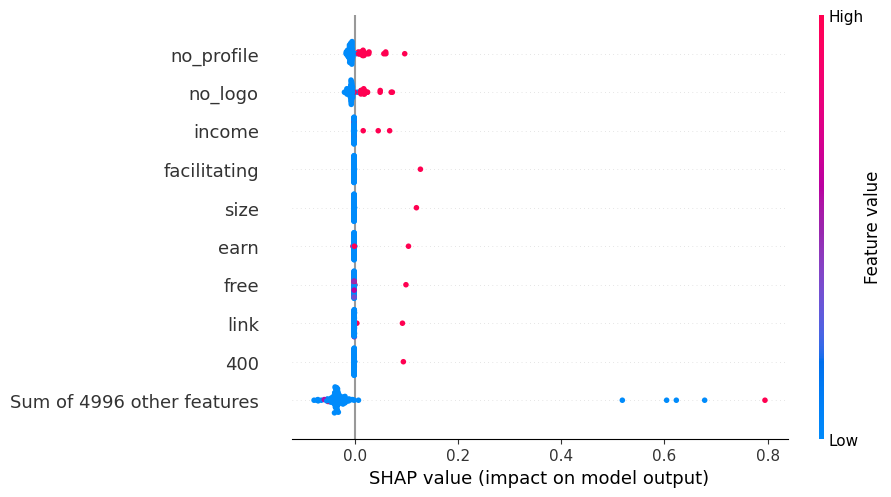

In [ ]:
shap_explanation_for_class_1 = shap_values[:, :, 1]
shap_explanation_for_class_1.feature_names = feature_names
shap.plots.beeswarm(shap_explanation_for_class_1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [ ]:
evaluate_model(lr, X_test, y_test, "Logistic Regression")
evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(svm, X_test, y_test, "SVM")
evaluate_model(knn, X_test, y_test, "KNN")


===== Logistic Regression =====
Accuracy: 0.9723154362416108

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.43      0.60       173

    accuracy                           0.97      3576
   macro avg       0.99      0.71      0.79      3576
weighted avg       0.97      0.97      0.97      3576

Confusion Matrix:
[[3403    0]
 [  99   74]]

===== Random Forest =====
Accuracy: 0.9793064876957495

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.97      0.59      0.73       173

    accuracy                           0.98      3576
   macro avg       0.98      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576

Confusion Matrix:
[[3400    3]
 [  71  102]]

===== SVM =====
Accuracy: 0.9843400447427293

Classification Report:
               pre

In [ ]:
import numpy as np
import pandas as pd

mean_shap = np.abs(shap_explanation_for_class_1.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_shap
})

shap_importance = shap_importance.sort_values(by="importance", ascending=False)

print(shap_importance.head(10))

           feature  importance
5001    no_profile    0.012774
5003       no_logo    0.011870
2267        income    0.002595
1764  facilitating    0.002546
4138          size    0.002391
1464          earn    0.002084
1926          free    0.001990
2630          link    0.001934
66             400    0.001886
1369     discounts    0.001884


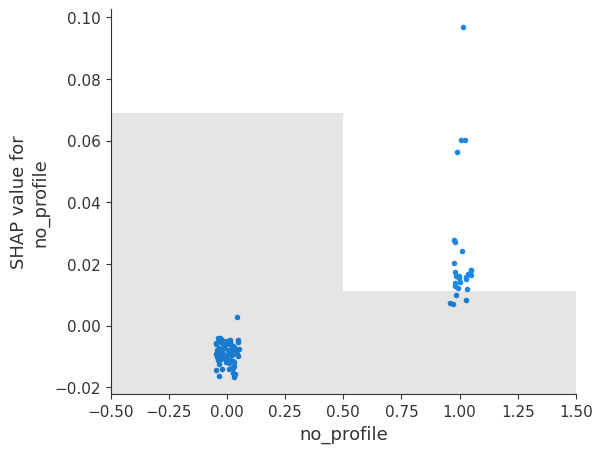

In [ ]:
shap.plots.scatter(shap_explanation_for_class_1[:, "no_profile"])

In [1]:
from sklearn.utils import resample

In [2]:
class_weight="balanced"